# BiLSTM Sentiment Classification

In [1]:
import ast
import pandas as pd

df = pd.read_csv("FINAL_BALANCED_FOR_M3.csv")

# Restore list columns serialized as strings
for col in ["pos_tags", "lemmatized"]:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

print(df.shape)
print(df.columns.tolist())
display(df.head())

(683532, 4)
['review_type', 'review_content', 'pos_tags', 'lemmatized']


,review_type,review_content,pos_tags,lemmatized
0,Rotten,A very disappointing version of the classic st...,"[(a, DT), (very, RB), (disappointing, JJ), (ve...","[disappointing, version, classic, stage, play]"
1,Rotten,"As expected, the soundtrack is the highlight o...","[(as, IN), (expected, VBN), (,, ,), (the, DT),...","[expect, soundtrack, highlight, idlewild, unfo..."
2,Fresh,It's a personal and profound work.,"[(it, PRP), (is, VBZ), (a, DT), (personal, JJ)...","[personal, profound, work]"
3,Fresh,"a deftly paced, expertly performed character s...","[(a, DT), (deftly, RB), (paced, VBN), (,, ,), ...","[deftly, pace, expertly, perform, character, s..."
4,Fresh,So what if it's sheer petty escapist enjoyment...,"[(so, RB), (what, WP), (if, IN), (it, PRP), (i...","[sheer, petty, escapist, enjoyment, tower, hei..."


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = df[["review_content", "review_type"]].dropna().copy()
df["review_content"] = df["review_content"].astype(str)
df["review_type"]    = df["review_type"].astype(str).str.strip()

print(df["review_type"].value_counts())

X = df["review_content"]
y = df["review_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded  = label_encoder.transform(y_test)

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

print("\nTrain size:", len(X_train))
print("Test size: ", len(X_test))

review_type
Rotten    341766
Fresh     341766
Name: count, dtype: int64
Label mapping:
0 = Fresh
1 = Rotten

Train size: 546825
Test size:  136707


## Tokenization and Sequence Padding

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Full-dataset setup
# MAX_LEN is reduced from 128 to 100 to make BiLSTM training faster while still keeping enough review context.
MAX_VOCAB = 20000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")

# Fit tokenizer on the FULL training set, not a sample.
tokenizer.fit_on_texts(X_train.astype(str))

X_train_seq = tokenizer.texts_to_sequences(X_train.astype(str))
X_test_seq  = tokenizer.texts_to_sequences(X_test.astype(str))

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

print("Using FULL dataset")
print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape: ", X_test_pad.shape)
print(f"Vocabulary size fitted: {len(tokenizer.word_index):,}")

Using FULL dataset
X_train_pad shape: (546825, 100)
X_test_pad shape:  (136707, 100)
Vocabulary size fitted: 121,850


### Full dataset enabled

The earlier sample-only block was removed.

The model now trains on:

- `X_train_pad`
- `y_train_encoded`

and evaluates on:

- `X_test_pad`
- `y_test_encoded`

This means the BiLSTM uses all available rows after cleaning and train/test splitting.

## Build BiLSTM Model

In [4]:
# Sanity check: these should match the FULL train/test split sizes.
print("Full training rows used:", X_train_pad.shape[0])
print("Full testing rows used: ", X_test_pad.shape[0])
print("Encoded train labels:", y_train_encoded.shape)
print("Encoded test labels: ", y_test_encoded.shape)

Full training rows used: 546825
Full testing rows used:  136707
Encoded train labels: (546825,)
Encoded test labels:  (136707,)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D

# Slightly smaller model for faster training on the full dataset.
# Main speed gains:
# 1. MAX_LEN reduced earlier
# 2. one BiLSTM layer instead of two stacked BiLSTM layers
# 3. larger batch size during training
EMBEDDING_DIM = 100
LSTM_UNITS = 64

model = Sequential([
    Embedding(
        input_dim=MAX_VOCAB,
        output_dim=EMBEDDING_DIM
    ),

    SpatialDropout1D(0.2),

    Bidirectional(LSTM(
        LSTM_UNITS,
        dropout=0.2,
        recurrent_dropout=0.0
    )),

    Dense(64, activation="relu"),
    Dropout(0.4),

    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train BiLSTM Model

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.1,
    epochs=5,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("Model training completed using the FULL training dataset.")

Epoch 1/5
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 837s 430ms/step - accuracy: 0.7983 - loss: 0.4301 - val_accuracy: 0.8347 - val_loss: 0.3713 - learning_rate: 0.0010
Epoch 2/5
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 877s 437ms/step - accuracy: 0.8475 - loss: 0.3487 - val_accuracy: 0.8417 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 3/5
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8661 - loss: 0.3107   
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 822s 427ms/step - accuracy: 0.8626 - loss: 0.3179 - val_accuracy: 0.8451 - val_loss: 0.3579 - learning_rate: 0.0010
Epoch 4/5
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.8837 - loss: 0.2759   
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 830s 432ms/step - accuracy: 0.8812 - loss: 0.2804 - val_accuracy: 0.8458 - val_loss: 0.3615 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from

## Training History

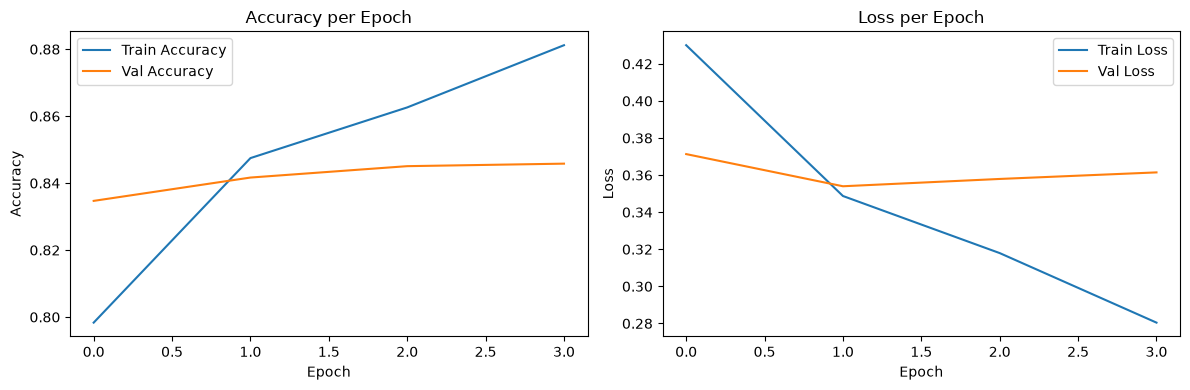

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluate BiLSTM Model

268/268 ━━━━━━━━━━━━━━━━━━━━ 92s 338ms/step 
Classification Report:
              precision    recall  f1-score   support

       Fresh     0.8659    0.8082    0.8361     68354
      Rotten     0.8202    0.8749    0.8466     68353

    accuracy                         0.8415    136707
   macro avg     0.8430    0.8415    0.8413    136707
weighted avg     0.8430    0.8415    0.8413    136707



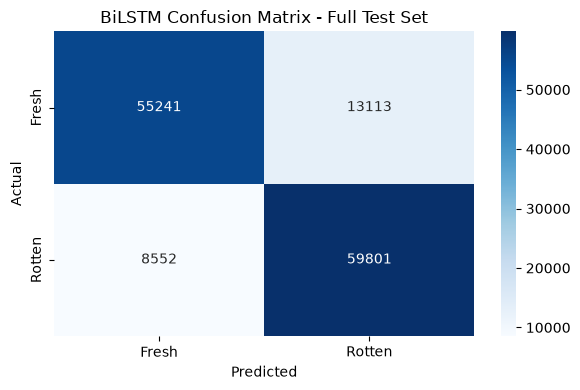

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test_pad, batch_size=512, verbose=1)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print("Classification Report:")
print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM Confusion Matrix - Full Test Set")
plt.tight_layout()
plt.show()

## Test with New Review

In [9]:
def predict_review_sentiment(review_text):
    seq  = tokenizer.texts_to_sequences([review_text])
    pad  = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    prob = model.predict(pad, verbose=0)[0][0]
    label = label_encoder.classes_[int(prob >= 0.5)]
    return f"{label} (confidence: {prob:.2%})"

sample_review = "The movie was emotional, well acted, and beautifully directed."
print("Prediction:", predict_review_sentiment(sample_review))

sample_review_2 = "The movie was boring, badly written, and too long."
print("Prediction:", predict_review_sentiment(sample_review_2))

Prediction: Fresh (confidence: 2.56%)
Prediction: Rotten (confidence: 98.77%)


## Save BiLSTM Model

In [10]:
import pickle

model.save("bilstm_sentiment_model.keras")

with open("bilstm_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("bilstm_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

bilstm_config = {
    "max_vocab": MAX_VOCAB,
    "max_len": MAX_LEN,
    "embedding_dim": EMBEDDING_DIM,
    "lstm_units": LSTM_UNITS,
    "uses_full_dataset": True
}

with open("bilstm_config.pkl", "wb") as f:
    pickle.dump(bilstm_config, f)

print("BiLSTM model, tokenizer, label encoder, and config saved successfully.")

BiLSTM model, tokenizer, label encoder, and config saved successfully.
